## 1. Importing Libraries & Loading Dataset


In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Iris dataset (Condition 1: No download required)
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Replacing numeric target with actual species names for better understanding
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Exploratory Data Analysis (EDA)
Checking the shape, data types, null values, and descriptive statistics.

In [2]:
# 1. Shape of the dataset
print("Shape of Dataset:", df.shape)

# 2. Data Types
print("\nData Types:\n", df.dtypes)

# 3. Null Value Check
print("\nNull Values Check:\n", df.isnull().sum())

# 4. Descriptive Statistics
print("\nDescriptive Statistics:\n", df.describe())

Shape of Dataset: (150, 5)

Data Types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Null Values Check:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive Statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        

## 3. Data Visualisations
Plotting box plots for each feature and a pairplot to see distributions.

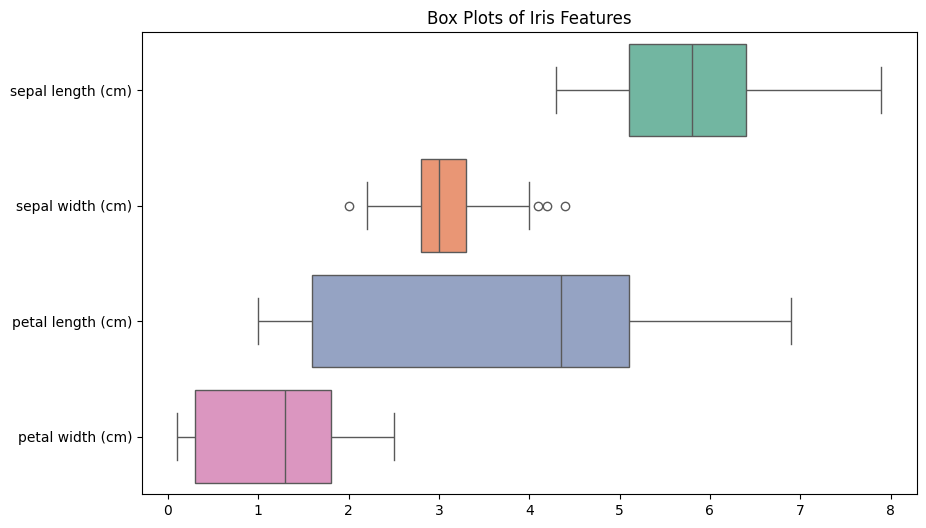

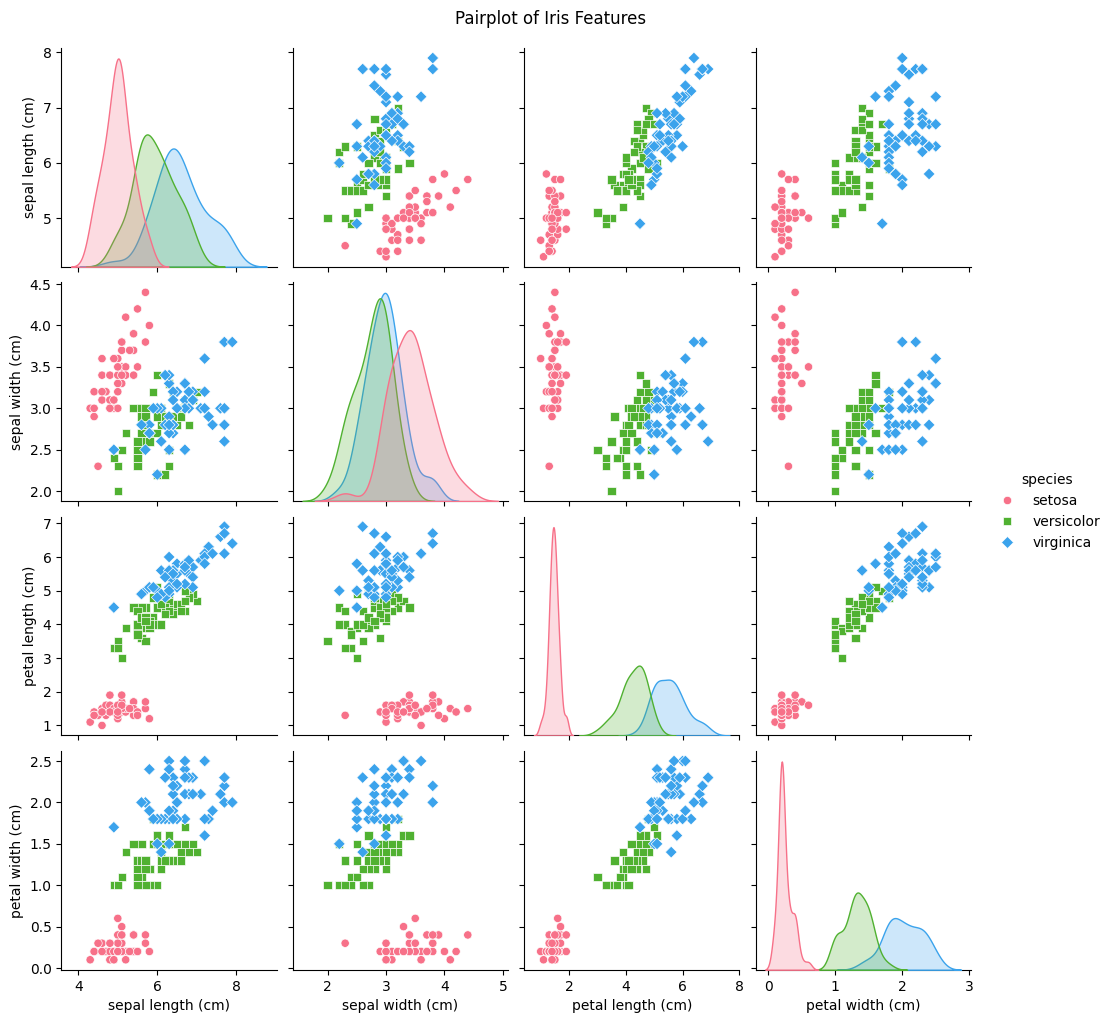

In [3]:
# Box plots for each feature
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('species', axis=1), orient="h", palette="Set2")
plt.title("Box Plots of Iris Features")
plt.show()

# Pairplot or Scatter Matrix
sns.pairplot(df, hue='species', markers=["o", "s", "D"], palette="husl")
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

## 4. Feature Selection Discussion
**Which features are most discriminative?**
By observing the pairplot above, we can clearly see that **Petal Length** and **Petal Width** are the most discriminative features. The *Setosa* species is completely separated from the other two based on these two features alone. While *Versicolor* and *Virginica* have a slight overlap, petal measurements still provide the clearest boundary compared to sepal length and width.

## 5. Train/Test Split
Splitting the data into 80% training and 20% testing sets.

In [4]:
# Separating features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


### 6. Model Training

Now, we will train two different classification models on our training data:
1. **Logistic Regression:** A fundamental classification algorithm.
2. **Random Forest Classifier:** An ensemble learning method that creates multiple decision trees.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Model 2: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Both models trained successfully!")

Both models trained successfully!


### 7. Model Evaluation

In this step, we will evaluate the performance of both trained models using the testing data. We will check the **Accuracy Score**, **Confusion Matrix**, and **Classification Report** (which includes precision, recall, and F1-score) for both models.

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- Logistic Regression Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

print("\n" + "="*50 + "\n")

print("--- Random Forest Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

--- Logistic Regression Performance ---
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



--- Random Forest Performance ---
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00  

### 8. Conclusion & Best Model Selection

After evaluating both models, we can observe that both Logistic Regression and Random Forest performed exceptionally well.

I declare **Random Forest** as the best-performing model because it is an ensemble learning method that generally handles complex datasets better and is more robust against overfitting.